In [12]:
import pandas as pd
import numpy as np
import importlib

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import utility_functions as uf

In [31]:
year = 1990
mode = "collaborative_"

In [32]:
df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year}.csv", index_col=0)
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

In [33]:
df_prob

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3600,3603,3604,3605,3607,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AE,NaN,0.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.055556,0.027778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VN,NaN,NaN,NaN,0.012500,NaN,0.01250,NaN,NaN,NaN,0.062500,...,0.037500,NaN,NaN,0.0125,NaN,NaN,NaN,NaN,NaN,NaN
YE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZA,0.006135,0.006135,0.006135,0.003067,0.015337,0.01227,0.003067,NaN,0.009202,0.018405,...,0.009202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003067,NaN


In [34]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [57]:
def jaccard_turn(a, b):
    intersect = a == b
    outer_a = a[~intersect].sum()
    outer_b = b[~intersect].sum()
    print(intersect.sum())
    return 2 * min(outer_a, outer_b) / (a[intersect].sum() + 2 * min(outer_a, outer_b))

def get_jaccard_turn_distances(df_metric):
    n_countries = len(df_metric.index)
    dist_array = np.full((n_countries, n_countries), np.nan)
    for i in range(n_countries):
        for j in range(n_countries):
            dist_array[i, j] = jaccard_turn(df_metric.iloc[i].fillna(0) > 0, df_metric.iloc[j].fillna(0) > 0)
    return pd.DataFrame(dist_array, index=df_metric.index, columns=df_metric.index)

In [58]:
df_dist = uf.get_jaccard_distances(df_prob)
df_dist_turn = get_jaccard_turn_distances(df_prob)

241
219
214
203
222
159
125
69
210
214
218
186
96
219
168
213
215
218
217
215
218
123
211
210
47
213
219
90
211
166
208
93
188
205
204
218
138
56
219
109
216
206
216
210
158
109
210
139
213
219
69
220
40
217
220
191
218
218
222
216
142
215
217
219
171
218
182
129
198
150
95
106
211
200
201
88
207
203
70
195
213
220
128
192
216
222
217
217
199
218
217
217
210
198
215
190
215
220
216
215
215
210
210
220
218
216
216
219
217
139
179
218
217
206
177
221
76
135
205
136
211
209
198
218
208
187
174
114
195
222
156
219
207
220
204
180
138
220
184
219
220
208
99
172
188
163
219
216
218
209
220
220
214
218
216
169
218
222
202
156
216
132
204
202
209
23
211
218
186
217
220
189
216
137
214
207
219
241
232
215
238
151
117
51
226
224
236
192
80
231
164
227
231
236
235
233
232
105
231
216
29
227
235
74
221
164
218
79
190
217
214
234
124
38
237
101
234
210
236
220
150
93
226
123
233
237
51
236
22
235
238
205
236
234
238
234
138
235
235
235
179
236
182
119
200
140
81
92
217
204
211
72
217
209
52
195
227

In [59]:
df_dist_turn

country,AE,AF,AL,AM,AO,AR,AT,AU,AZ,BA,...,UY,UZ,VE,VG,VI,VN,YE,ZA,ZM,ZW
country,,,,,,,,,,,,,,,,,,,,,
AE,0.000000,1.000000,1.000000,0.888889,0.0,0.461538,0.400000,0.000000,0.960000,0.846154,...,0.923077,0.888889,0.787879,1.000000,1.0,0.823529,1.000000,0.333333,0.900000,0.918919
AF,1.000000,0.000000,1.000000,0.666667,1.0,0.666667,0.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,0.666667,1.000000,1.000000,1.000000,0.666667
AL,1.000000,1.000000,0.000000,0.727273,1.0,0.444444,0.250000,0.000000,0.923077,1.000000,...,0.923077,0.888889,0.833333,1.000000,1.0,0.923077,1.000000,0.444444,1.000000,0.833333
AM,0.888889,0.666667,0.727273,0.000000,1.0,0.631579,0.322581,0.074074,0.818182,0.965517,...,0.880000,0.888889,0.818182,1.000000,1.0,0.790698,0.888889,0.514286,0.705882,0.857143
AO,0.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,1.0,1.000000,1.000000,0.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VN,0.823529,0.666667,0.923077,0.790698,1.0,0.603175,0.307692,0.044444,0.700000,0.800000,...,0.666667,0.750000,0.742857,0.857143,1.0,0.000000,0.750000,0.370370,0.625000,0.823529
YE,1.000000,1.000000,1.000000,0.888889,1.0,0.333333,0.333333,0.000000,0.571429,0.888889,...,0.750000,0.750000,0.571429,0.857143,1.0,0.750000,0.000000,0.333333,1.000000,1.000000
ZA,0.333333,1.000000,0.444444,0.514286,0.0,0.348624,0.453333,0.129032,0.142857,0.421053,...,0.133333,0.000000,0.366667,0.000000,0.0,0.370370,0.333333,0.000000,0.166667,0.333333


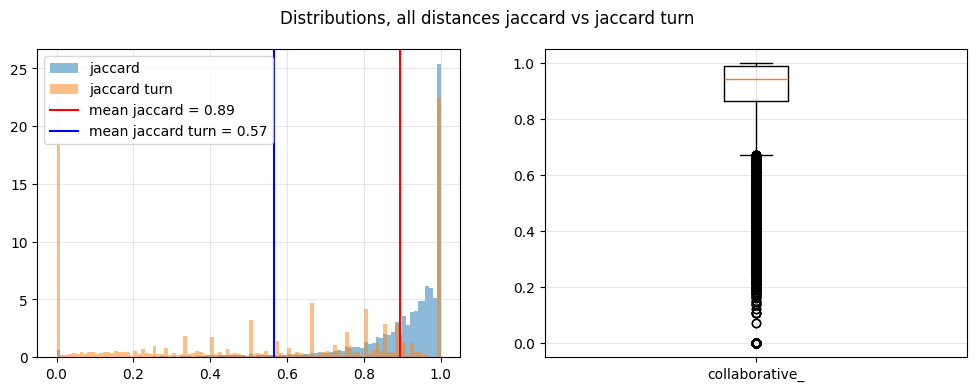

In [60]:
fig, (ax1, ax2) =plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

data1 = df_dist.values.flatten()
data1 = data1[~np.isnan(data1)]

data2 = df_dist_turn.values.flatten()
data2 = data2[~np.isnan(data2)]

ax1.hist(data1, bins=100, alpha=0.5, label="jaccard", density=True)
ax1.hist(data2, bins=100, alpha=0.5, label="jaccard turn", density=True)
ax1.axvline(data1.mean(), color="red", label=f"mean jaccard = {round(data1.mean(), 2)}")
ax1.axvline(data2.mean(), color="blue", label=f"mean jaccard turn = {round(data2.mean(), 2)}")
ax1.legend()
ax1.grid(alpha=0.3)
# plt.show()

plt.subplot(1, 2, 2)

ax2.boxplot([data1])
ax2.set_xticks([1], [mode])
ax2.grid(alpha=0.3)

plt.suptitle("Distributions, all distances jaccard vs jaccard turn")
plt.show()

In [62]:
uf.plotly_heatmap(
    df_dist_turn,
    x_labels=df_dist.columns,
    y_labels=df_dist.index,
    z_min=0, z_max=1,
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {mode[:-1]}, {year}",
)

In [70]:
D = df_dist_turn.values

In [68]:
from sklearn.cluster import AgglomerativeClustering

# D = df_dist.values

model = AgglomerativeClustering(n_clusters=20, metric='precomputed', linkage='average')

labels = model.fit_predict(D)

score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(-0.21054887787759008)

In [87]:
from sklearn.cluster import DBSCAN

# D = df_dist.values

model = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
labels = model.fit_predict(D)
# score = silhouette_score(D, labels, metric="precomputed")
# score

In [92]:
# Example: distance matrix (symmetric, zeros on diagonal)
# D = df_dist.values

# Convert to condensed form (required by linkage)
condensed_D = squareform(D)

# Perform hierarchical clustering
# method can be: 'single', 'complete', 'average', 'ward'
Z = linkage(condensed_D, method='average')

labels = fcluster(Z, t=0.05, criterion='distance')
order = np.argsort(labels)

score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.2315340909090909)

In [93]:
df_map = (
    df_dist
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region", "sub-region"]], left_index=True, right_on="alpha-2", how="left")
    [["alpha-2", "alpha-3", "name", "sub-region", "region"]]
    .assign(cluster=labels,
            cluster_str = lambda df: df["cluster"].astype(str))
    .rename(columns={"alpha-3": "country", "alpha-2": "country2"})
)
df_map.sample(5)

,country2,country,name,sub-region,region,cluster,cluster_str
167,OM,OMN,Oman,Western Asia,Asia,74,74
123,LV,LVA,Latvia,Northern Europe,Europe,6,6
205,SO,SOM,Somalia,Sub-Saharan Africa,Africa,107,107
179,PR,PRI,Puerto Rico,Latin America and the Caribbean,Americas,42,42
120,KW,KWT,Kuwait,Western Asia,Asia,41,41


(<Figure size 1200x600 with 2 Axes>, <Axes: title={'center': ' '}>)

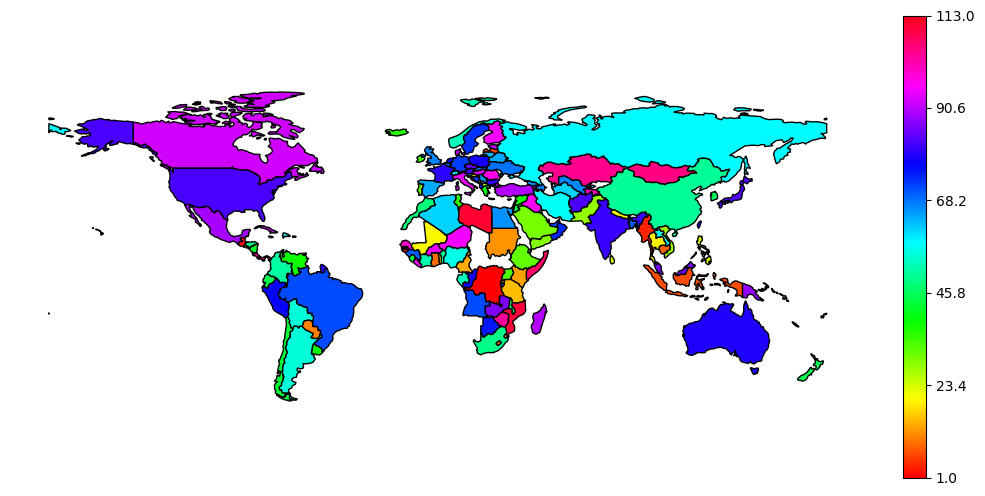

In [94]:
uf.plot_map_continuous(df_map, "cluster", country_column="country")